In [40]:
# %pip install -r ../requirements.txt 

# Set up database

In [41]:
from dotenv import load_dotenv
import os

load_dotenv()

user = os.getenv("DB_USER")
password = os.getenv("DB_PASS")
host = os.getenv("DB_HOST")
dbname = os.getenv("DB_NAME")

from sqlalchemy import create_engine
engine = create_engine(f"mysql+mysqlconnector://{user}:{password}@{host}/{dbname}", connect_args={'init_command': 'SET time_zone="+07:00"'})

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.table import Table

# Simple statistical

In [43]:
query = """
SELECT timestampdiff(MINUTE, ACTLOG_START, AO_FINISH) as TIME_READING,
    BREAK_TIME,
    CASE
        WHEN FOCUS_LEVEL IN ('very_low', 'low') THEN 1
        WHEN FOCUS_LEVEL = 'medium' THEN 2
        WHEN FOCUS_LEVEL IN ('high', 'very_high') THEN 3
        ELSE NULL
    END AS FOCUS_LEVEL,
    TOTAL_COUNT as PAGES,
    CASE
        WHEN CONTENT_LEVEL IN ('very_easy', 'easy') THEN 1
        WHEN CONTENT_LEVEL = 'moderate' THEN 2
        WHEN CONTENT_LEVEL IN ('hard', 'very_hard') THEN 3
        ELSE NULL
    END AS CONTENT_LEVEL_ENUM
FROM ACTIVITY
    natural join ACTIVITY_LOG
    natural join ACTIVITY_OUTPUT
    natural join KIT_COUNT
    natural join KIT_READING
where (TRANSLATION is not null)
    and (ACTIVITY_ID=12)
    and (unit_count like 'pages');
        """
ps = pd.read_sql(query, engine)
ps.head()

,TIME_READING,BREAK_TIME,FOCUS_LEVEL,PAGES,CONTENT_LEVEL_ENUM
0,45,3,2,4.0,3
1,76,0,3,3.0,3
2,60,0,3,4.0,3
3,79,0,3,7.0,3
4,99,0,3,6.0,3


/var/folders/20/3dpkl8y92xs2mr9bxxsnt9j40000gn/T/ipykernel_65572/2554123881.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax4.boxplot(


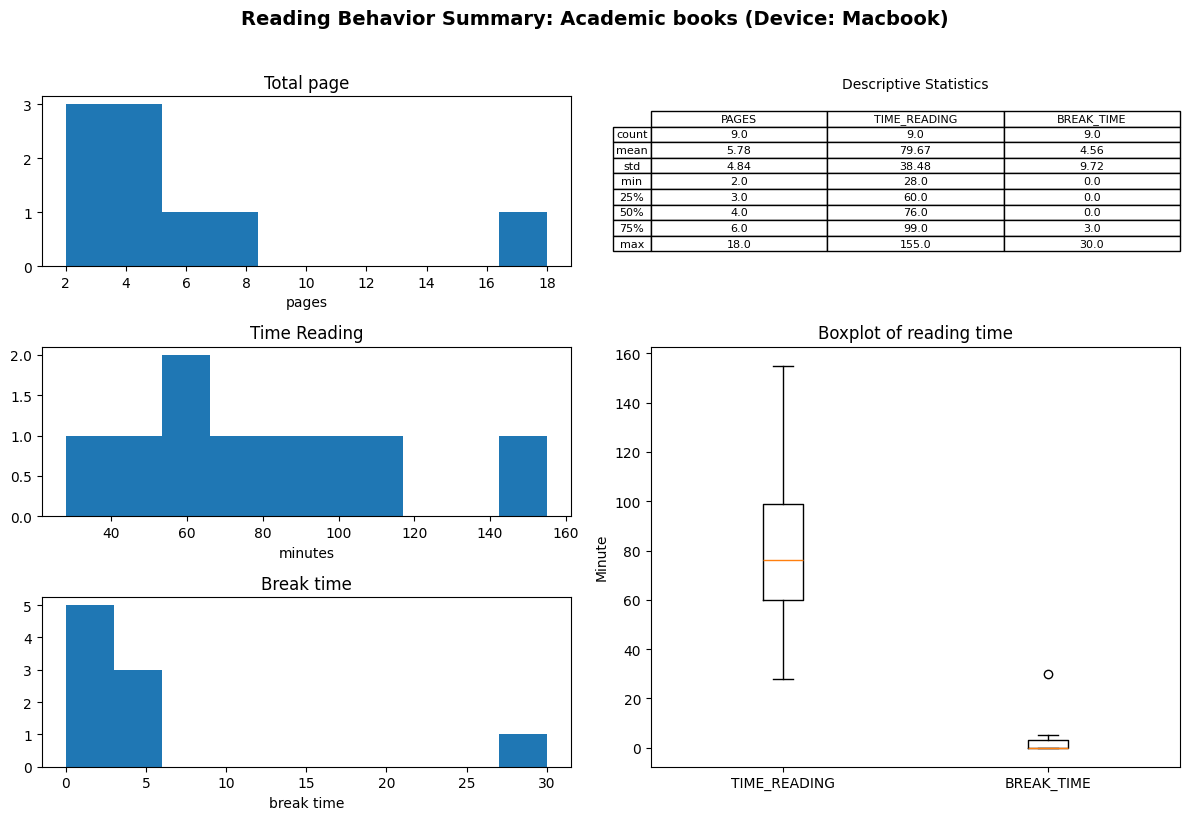

In [44]:
fig = plt.figure(figsize=(12, 8))
gs = GridSpec(3, 2, figure=fig)

desc = ps[['PAGES', 'TIME_READING', 'BREAK_TIME']].describe().round(2)

ax_table = fig.add_subplot(gs[0, 1])
ax_table.axis('off')
table = ax_table.table(
    cellText=desc.values,
    rowLabels=desc.index,
    colLabels=desc.columns,
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1)
for key, cell in table.get_celld().items():
    cell.set_text_props(ha='center', va='center')
ax_table.set_title('Descriptive Statistics', fontsize=10)

# --- Plot 1 ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(ps['PAGES'])
ax1.set_xlabel("pages")
ax1.set_title("Total page")

# --- Plot 2 ---
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(ps['TIME_READING'])
ax2.set_xlabel("minutes")
ax2.set_title("Time Reading")

# --- Plot 3 ---
ax3 = fig.add_subplot(gs[2, 0])
ax3.hist(ps['BREAK_TIME'])
ax3.set_xlabel("break time")
ax3.set_title("Break time")

# --- Boxplot ---
ax4 = fig.add_subplot(gs[1:, 1])
ax4.boxplot(
    [ps['TIME_READING'].dropna(), ps['BREAK_TIME'].dropna()],
    labels=['TIME_READING', 'BREAK_TIME']
)
ax4.set_title('Boxplot of reading time')
ax4.set_ylabel('Minute')

fig.suptitle("Reading Behavior Summary: Academic books (Device: Macbook)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [45]:
# Get means of both columns
means = ps[['PAGES', 'TIME_READING']].mean()
print(means[0], means[1])

5.777777777777778 79.66666666666667


/var/folders/20/3dpkl8y92xs2mr9bxxsnt9j40000gn/T/ipykernel_65572/2580457362.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(means[0], means[1])


In [46]:
def total_day(totalPages, hoursSpentPerDay):
    return (((totalPages * means[1])/means[0])/60)/hoursSpentPerDay

In [47]:
print(total_day(totalPages=121, hoursSpentPerDay=5))

5.561346153846155


/var/folders/20/3dpkl8y92xs2mr9bxxsnt9j40000gn/T/ipykernel_65572/966302175.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (((totalPages * means[1])/means[0])/60)/hoursSpentPerDay


# Model

## Logistic regression classification

Just provide the book's difficulty level and the number of minutes you plan to read; the model will predict how many pages you will finish (good means finishing more than 5 pages/hour, bad means less than 5 pages/hour)

In [48]:
query = """
SELECT timestampdiff(MINUTE, ACTLOG_START, AO_FINISH) as TIME_READING,
    BREAK_TIME,
    CASE
        WHEN FOCUS_LEVEL IN ('very_low', 'low') THEN 1
        WHEN FOCUS_LEVEL = 'medium' THEN 2
        WHEN FOCUS_LEVEL IN ('high', 'very_high') THEN 3
        ELSE NULL
    END AS FOCUS_LEVEL,
    TOTAL_COUNT as PAGES,
    CASE
        WHEN CONTENT_LEVEL IN ('very_easy', 'easy') THEN 1
        WHEN CONTENT_LEVEL = 'moderate' THEN 2
        WHEN CONTENT_LEVEL IN ('hard', 'very_hard') THEN 3
        ELSE NULL
    END AS CONTENT_LEVEL_ENUM,
    CASE 
        WHEN (TOTAL_COUNT / timestampdiff(MINUTE, ACTLOG_START, AO_FINISH))*60 < 3 THEN 'bad'
        WHEN (TOTAL_COUNT / timestampdiff(MINUTE, ACTLOG_START, AO_FINISH))*60 >= 3 AND (TOTAL_COUNT / timestampdiff(MINUTE, ACTLOG_START, AO_FINISH))*60 <= 6 THEN 'medium'
        WHEN (TOTAL_COUNT / timestampdiff(MINUTE, ACTLOG_START, AO_FINISH))*60 > 6 THEN 'good'
        ELSE NULL
    END AS PAGES_PER_HOUR_RATING
FROM ACTIVITY
    natural join ACTIVITY_LOG
    natural join ACTIVITY_OUTPUT
    natural join KIT_COUNT
    natural join KIT_READING
where (TRANSLATION is not null)
    and (ACTIVITY_ID=12)
    and (unit_count like 'pages');
        """
ps = pd.read_sql(query, engine)
ps.head()

,TIME_READING,BREAK_TIME,FOCUS_LEVEL,PAGES,CONTENT_LEVEL_ENUM,PAGES_PER_HOUR_RATING
0,45,3,2,4.0,3,medium
1,76,0,3,3.0,3,bad
2,60,0,3,4.0,3,medium
3,79,0,3,7.0,3,medium
4,99,0,3,6.0,3,medium


/Users/chibangnguyen/.pyenv/versions/LearningDB-py3.13.5/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


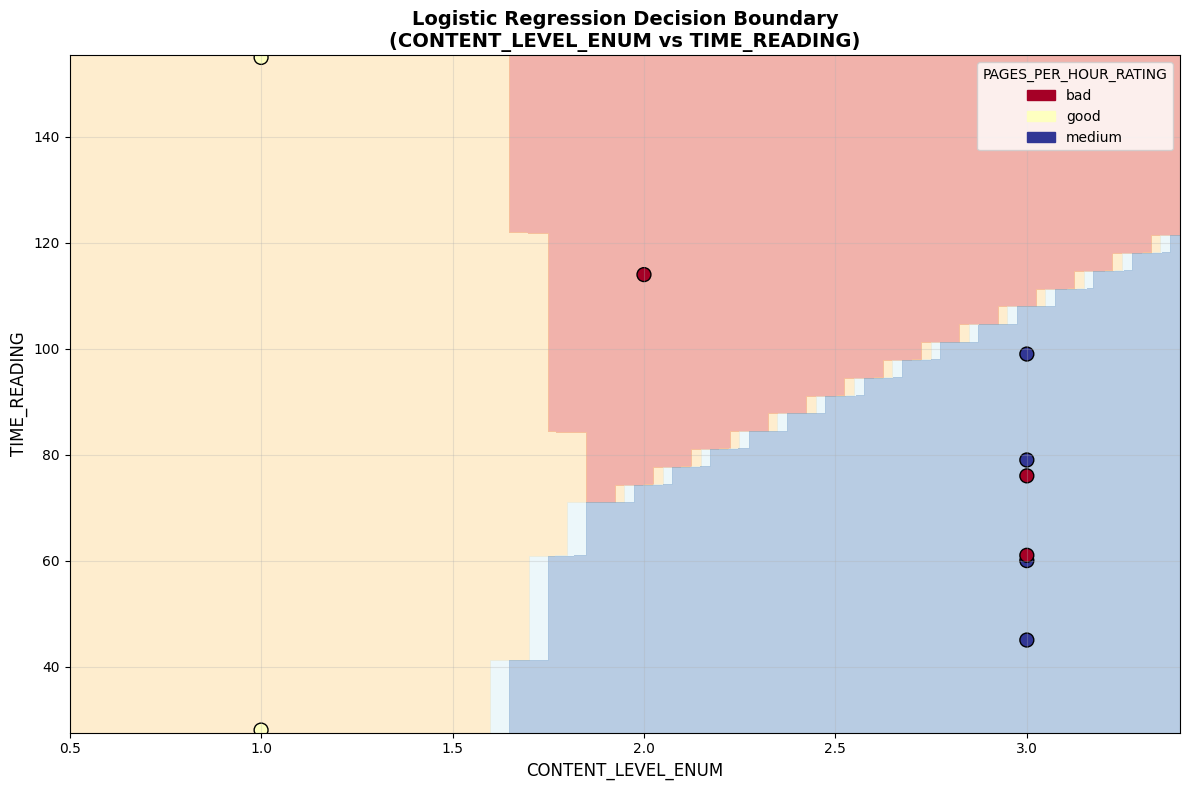

Model Accuracy: 0.7778
Model Coefficients: [[ 0.32628126  0.00568978]
 [-1.0991764   0.001897  ]
 [ 0.77289514 -0.00758679]]
Model Intercept: [-0.99281557  1.89271154 -0.89989597]
Class mapping (label->encoded): {'bad': 0, 'good': 1, 'medium': 2}


In [49]:
# Logistic Regression với Decision Boundary (multi-class: bad, medium, good)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Chuẩn bị dữ liệu
# Loại bỏ các dòng có giá trị NULL
ps_clean = ps.dropna(subset=['CONTENT_LEVEL_ENUM', 'TIME_READING', 'PAGES_PER_HOUR_RATING'])

# Tạo features (X) và target (y)
X = ps_clean[['CONTENT_LEVEL_ENUM', 'TIME_READING']].values
y = ps_clean['PAGES_PER_HOUR_RATING'].values

# Encode target variable (bad=0, medium=1, good=2)
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # Now: 0=bad, 1=good, 2=medium or lexicographically, let's get classes:
classes = list(le.classes_)  # For consistent mapping to legend

# Train Logistic Regression model (multi-class)
lr_model = LogisticRegression(multi_class="multinomial", solver="lbfgs")
lr_model.fit(X, y_encoded)

# Tạo meshgrid để vẽ decision boundary
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Dự đoán trên meshgrid
Z = lr_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Vẽ decision boundary
import matplotlib.patches as mpatches
plt.figure(figsize=(12, 8))
contour = plt.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu', levels=len(le.classes_))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y_encoded, cmap='RdYlBu', edgecolors='black', s=100)
plt.xlabel('CONTENT_LEVEL_ENUM', fontsize=12)
plt.ylabel('TIME_READING', fontsize=12)
plt.title('Logistic Regression Decision Boundary\n(CONTENT_LEVEL_ENUM vs TIME_READING)', fontsize=14, fontweight='bold')

# Tạo legend tự động theo nhãn
cmap = plt.cm.RdYlBu
handles = [
    mpatches.Patch(color=cmap(i / max(2, len(classes)-1)), label=cls)
    for i, cls in enumerate(classes)
]
plt.legend(handles=handles, title='PAGES_PER_HOUR_RATING', loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# In thông tin model
print(f"Model Accuracy: {lr_model.score(X, y_encoded):.4f}")
print(f"Model Coefficients: {lr_model.coef_}")
print(f"Model Intercept: {lr_model.intercept_}")
print("Class mapping (label->encoded):", dict(zip(classes, range(len(classes)))))

In [50]:
# Function để dự đoán PAGES_PER_HOUR_RATING
def predict_rating(content_level_enum, time_reading):
    """
    Dự đoán PAGES_PER_HOUR_RATING dựa trên CONTENT_LEVEL_ENUM và TIME_READING
    
    Parameters:
    -----------
    content_level_enum : int
        Mức độ khó của nội dung (1=easy, 2=moderate, 3=hard)
    time_reading : float
        Thời gian đọc (phút)
    
    Returns:
    --------
    dict : Dictionary chứa prediction và probability cho tất cả các nhãn (PAGES_PER_HOUR_RATING)
        - prediction: 'bad', 'medium', hoặc 'good'
        - probability: Xác suất của prediction
        - probabilities: dict với xác suất cho mỗi nhãn: {'bad':..., 'medium':..., 'good':...}
        - content_level_enum: Giá trị input
        - time_reading: Giá trị input
    """
    # Kiểm tra input
    if content_level_enum not in [1, 2, 3]:
        raise ValueError("CONTENT_LEVEL_ENUM phải là 1, 2, hoặc 3")
    if time_reading < 0:
        raise ValueError("TIME_READING phải là số dương")
    
    # Tạo input array
    X_input = np.array([[content_level_enum, time_reading]])
    
    # Dự đoán
    prediction_encoded = lr_model.predict(X_input)[0]
    probabilities = lr_model.predict_proba(X_input)[0]
    
    # Decode prediction
    prediction_label = le.inverse_transform([prediction_encoded])[0]

    # Lấy xác suất theo đúng nhãn và ánh xạ xác suất theo tên nhãn
    prob_dict = {cls: float(probabilities[i]) for i, cls in enumerate(le.classes_)}
    prob_of_pred = float(prob_dict.get(prediction_label, 0.0))
    
    return {
        'prediction': prediction_label,
        'probability': prob_of_pred,
        'probabilities': prob_dict,
        'content_level_enum': content_level_enum,
        'time_reading': time_reading
    }

In [51]:
tests = [
    (3, 60),
    (3, 4*60),
    (1, 100),
    (2, 90),
]

In [52]:
for content_level, time_reading in tests:
    result = predict_rating(content_level, time_reading)
    print(f"Độ khó tài liệu: {result['content_level_enum']}, Thời gian đọc: {result['time_reading']} phút")
    print(f"Dự đoán: {result['prediction']}")
    print(f"Xác suất good là: {result['probabilities'].get('good', 0.0):.4f}")
    print(f"Xác suất bad là: {result['probabilities'].get('bad', 0.0):.4f}\n")

Độ khó tài liệu: 3, Thời gian đọc: 60 phút
Dự đoán: medium
Xác suất good là: 0.0642
Xác suất bad là: 0.3239

Độ khó tài liệu: 3, Thời gian đọc: 240 phút
Dự đoán: bad
Xác suất good là: 0.0787
Xác suất bad là: 0.7854

Độ khó tài liệu: 1, Thời gian đọc: 100 phút
Dự đoán: good
Xác suất good là: 0.6695
Xác suất bad là: 0.2272

Độ khó tài liệu: 2, Thời gian đọc: 90 phút
Dự đoán: bad
Xác suất good là: 0.2889
Xác suất bad là: 0.3926

